# Taylor Modeling Examples

This notebook provides examples of how to use the taylorm library.  The taylorm library is a custom developed library for performing verified computations with Taylor models.  It is built off the intvmath and polynomialmath libraries.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from verified_computing import taylorm
from verified_computing import intvmath

## Examples of how to use the basic operations

Basic operations supported:
* Taylor model addition
* Taylor model subtraction
* Taylor model multiplication
* Taylor model evaluation
* Taylor model bounding

## Printing

A Taylor model can be convieniently printed.


In [2]:
print('Taylor model printing examples:')

t1 = taylorm.TaylorModel(np.array([4, 3, 2, 1]), -1, 1)
t2 = taylorm.TaylorModel(np.array([1, -2, 3.1, -10]), -0.1, 0.1)
t1.print()
t2.print()

Taylor model printing examples:
 4*x^3 + 3*x^2 + 2*x + 1 + [-1, 1]
 x^3 - 2.0*x^2 + 3.1*x - 10.0 + [-0.1, 0.1]


## Copying

A Taylor Model can be copied.  The copy will use different memory from the original.


In [3]:
t1 = taylorm.TaylorModel(np.array([4, 3, 2, 1]), -1, 1)
t1_copy = t1.copy()

t1_copy.print()

 4*x^3 + 3*x^2 + 2*x + 1 + [-1, 1]


## Plotting

A Taylor model can be convieniently plotted.  Note that since we used pi as the bound to compute the remainder the Taylor model is only valid inside [-pi, pi].


<class 'matplotlib.axes._subplots.AxesSubplot'>


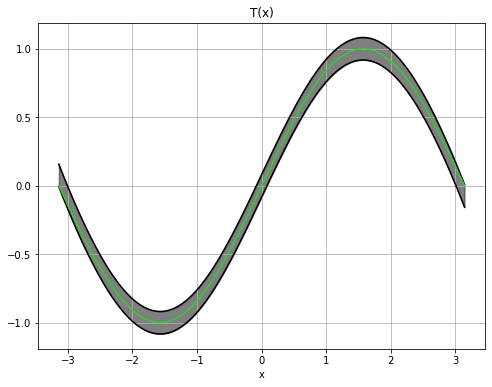

In [4]:
outer_bound = np.pi

# Use the Taylor coefficients for sin(x)
sin_coefs = np.array([
    -1/5040, 0, 1/120, 0, -1/6, 0, 1, 0], dtype=np.float64)

# Use the Taylor remainder formula to compute the remainder
big_n = sin_coefs.shape[0]
sin_remainder = np.abs(outer_bound) ** (big_n + 1) / np.math.factorial(big_n + 1)

t1 = taylorm.TaylorModel(sin_coefs, -sin_remainder, sin_remainder)

# Plot the Taylor model
ax = t1.plot(-outer_bound, outer_bound, n_points=100)

# Plot the original function for refference
x = np.linspace(-outer_bound, outer_bound, 50)
ax.plot(x, np.sin(x), color='limegreen')


## Addition

Taylor models can be added together.


In [5]:
t1 = taylorm.TaylorModel(np.array([4, 3, 2, 1]), -1, 1)
t2 = taylorm.TaylorModel(np.array([1, -2, 3.1, -10]), -0.1, 0.1)
tr = t1 + t2

print('({})  +  ({})'.format(t1.tostr(), t2.tostr()))
print('  = {}'.format(tr.tostr()))
print()

( 4*x^3 + 3*x^2 + 2*x + 1 + [-1, 1])  +  ( x^3 - 2.0*x^2 + 3.1*x - 10.0 + [-0.1, 0.1])
  =  5.0*x^3 + x^2 + 5.1*x - 9.0 + [-1.1, 1.1]



## Scalar Addition

A scalar can be added to a Taylor Model.

In [6]:
t1 = taylorm.TaylorModel(np.array([4.0, 3.0, 2.0, 1.0]), -1, 1)
scalar = 2.2
t2 = taylorm.add_scalar_to_taylor_model(scalar, t1)


print('({})  +  ({})'.format(t1.tostr(), scalar))
print('  = {}'.format(t2.tostr()))
print()

( 4.0*x^3 + 3.0*x^2 + 2.0*x + 1.0 + [-1, 1])  +  (2.2)
  =  4.0*x^3 + 3.0*x^2 + 2.0*x + 3.2 + [-1, 1]



## Subtraction

Taylor models can be subtracted.


In [7]:
t1 = taylorm.TaylorModel(np.array([4, 3, 2, 1]), -1, 1)
t2 = taylorm.TaylorModel(np.array([1, -2, 3.1, -10]), -0.1, 0.1)
tr = t1 - t2

print('({})  -  ({})'.format(t1.tostr(), t2.tostr()))
print('  = {}'.format(tr.tostr()))
print()

( 4*x^3 + 3*x^2 + 2*x + 1 + [-1, 1])  -  ( x^3 - 2.0*x^2 + 3.1*x - 10.0 + [-0.1, 0.1])
  =  3.0*x^3 + 5.0*x^2 - 1.1*x + 11.0 + [-1.1, 1.1]



## Multiplication

Taylor models can be multiplied.


In [8]:
t1 = taylorm.TaylorModel(np.array([4, 3, 2, 1]), -1, 1)
t2 = taylorm.TaylorModel(np.array([1, -2, 3.1, -10]), -0.1, 0.1)
x_min = -1
x_max = 1
tr = taylorm.multiply_taylor_models(t1, t2, x_min, x_max, n_subdomains=100)

print('({})  *  ({})'.format(t1.tostr(), t2.tostr()))
print('  = {}'.format(tr.tostr()))
print()

( 4*x^3 + 3*x^2 + 2*x + 1 + [-1, 1])  *  ( x^3 - 2.0*x^2 + 3.1*x - 10.0 + [-0.1, 0.1])
  =  -33.7*x^3 - 25.8*x^2 - 16.9*x - 10.0 + [-17.200000016000004, 34.6]



## Scalar Multiplication

Taylor models can be multiplied by scalars.


In [9]:
t1 = taylorm.TaylorModel(np.array([4.0, 3.0, 2.0, 1.0]), -1, 1)
scalar = 2.0
t2 = taylorm.multiply_taylor_model_by_scalar(scalar, t1)


print('({})  *  ({})'.format(t1.tostr(), scalar))
print('  = {}'.format(t2.tostr()))
print()

( 4.0*x^3 + 3.0*x^2 + 2.0*x + 1.0 + [-1, 1])  *  (2.0)
  =  8.0*x^3 + 6.0*x^2 + 4.0*x + 2.0 + [-2.0, 2.0]



## Example: sin(x) * sin(2*x)

This example uses Taylor models to multiply two functions together.


<class 'matplotlib.axes._subplots.AxesSubplot'>
<class 'matplotlib.axes._subplots.AxesSubplot'>
<class 'matplotlib.axes._subplots.AxesSubplot'>


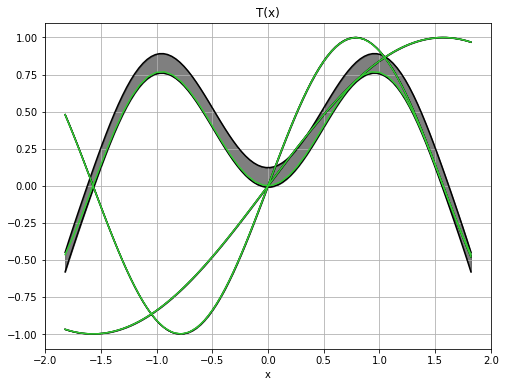

In [10]:
outer_bound = np.pi/2 + 0.25

# Coefficients
sin_x_coefs = np.array([
    1/62270208000, 0, -1/39916800, 0, 1/362880, 0, -1/5040, 0, 1/120, 0, -1/6, 0, 1, 0],
    dtype=np.float64)

sin_2x_coefs = np.array([
    8/6081075, 0, -8/155925, 0, 4/2835, 0, -8/315, 0, 4/15, 0, -4/3, 0, 2, 0],
    dtype=np.float64)

# Remainder bounds
big_n = sin_x_coefs.shape[0]
sin_x_remainder = np.abs(outer_bound) ** (big_n + 1) / np.math.factorial(big_n + 1)
sin_2x_remainder = np.abs(2*outer_bound) ** (big_n + 1) / np.math.factorial(big_n + 1)

# Taylor models
t_sin_x = taylorm.TaylorModel(sin_x_coefs, -sin_x_remainder, sin_x_remainder)
t_sin_2x = taylorm.TaylorModel(sin_2x_coefs, -sin_2x_remainder, sin_2x_remainder)
t_result = taylorm.multiply_taylor_models(
    t_sin_x, t_sin_2x, -outer_bound, outer_bound, n_subdomains=10)

# Plot the Taylor models
ax = t_sin_x.plot(-outer_bound, outer_bound, n_points=100)
ax = t_sin_2x.plot(-outer_bound, outer_bound, n_points=100, ax=ax)
ax = t_result.plot(-outer_bound, outer_bound, n_points=100, ax=ax)

# Plot the true functions
x = np.linspace(-outer_bound, outer_bound, 50)
ax.plot(x, np.sin(x), color='limegreen')
ax.plot(x, np.sin(2*x), color='limegreen')
ax.plot(x, np.sin(x)*np.sin(2*x), color='limegreen')


## Integer Exponentiation

Taylor models can be raised to an integer power.
 

In [11]:
t1 = taylorm.TaylorModel(np.array([4, 3, 2, 1]), -1, 1)
int_exp = 4
x_min = -1
x_max = 1
tr = taylorm.pown_taylor_model(t1, int_exp, x_min, x_max, n_subdomains=100)

print('({})  ^  ({})'.format(t1.tostr(), int_exp))
print('  = {}'.format(tr.tostr()))
print()

t1 = taylorm.TaylorModel(np.array([4, 3, 2, 1]), -1, 1)
int_exp = 0
x_min = -1
x_max = 1
tr = taylorm.pown_taylor_model(t1, int_exp, x_min, x_max, n_subdomains=100)

print('({})  ^  ({})'.format(t1.tostr(), int_exp))
print('  = {}'.format(tr.tostr()))
print()

( 4*x^3 + 3*x^2 + 2*x + 1 + [-1, 1])  ^  (4)
  =  120*x^3 + 36*x^2 + 8*x + 1 + [-4641.000011686399, 14476.0]

( 4*x^3 + 3*x^2 + 2*x + 1 + [-1, 1])  ^  (0)
  = 1 + [0, 0]



## Example: sin(x) ^ 9

Use Taylor models to raise sin(x) to an integer power.


<class 'matplotlib.axes._subplots.AxesSubplot'>
<class 'matplotlib.axes._subplots.AxesSubplot'>


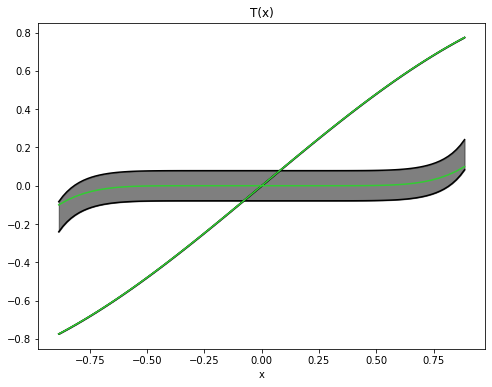

In [12]:
# Outer bounds
outer_bound = np.pi/4 + 0.1

# Exponent
int_exp = 9

# Coefficients
sin_x_coefs = np.array([
    1/62270208000, 0, -1/39916800, 0, 1/362880, 0, -1/5040, 0, 1/120, 0, -1/6, 0, 1, 0],
    dtype=np.float64)

# Remainder bounds
big_n = sin_x_coefs.shape[0]
sin_x_remainder = np.abs(outer_bound) ** (big_n + 1) / np.math.factorial(big_n + 1)

# Taylor models
t_sin_x = taylorm.TaylorModel(sin_x_coefs, -sin_x_remainder, sin_x_remainder)
t_result = taylorm.pown_taylor_model(
    t_sin_x, int_exp, -outer_bound, outer_bound, n_subdomains=20)

# Plot the Taylor models
ax = t_sin_x.plot(-outer_bound, outer_bound, n_points=100)
ax = t_result.plot(-outer_bound, outer_bound, n_points=100, ax=ax)

# Plot the true functions
x = np.linspace(-outer_bound, outer_bound, 50)
ax.plot(x, np.sin(x), color='limegreen')
ax.plot(x, np.sin(x)**int_exp, color='limegreen')

## Composing Taylor Models

Taylor models can be composed to compute non-trivial functions.

This example composes sin(x) with sin(x) to compute sin( sin(x) ).


<class 'matplotlib.axes._subplots.AxesSubplot'>
<class 'matplotlib.axes._subplots.AxesSubplot'>


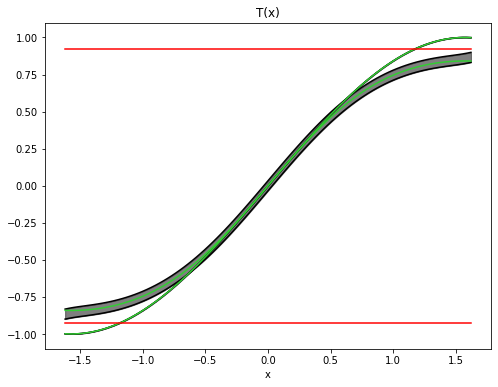

In [13]:
outer_bound = np.pi/2 + 0.05

# Coefficients
sin_x_coefs = np.array([
    1/62270208000, 0, -1/39916800, 0, 1/362880, 0, -1/5040, 0, 1/120, 0, -1/6, 0, 1, 0],
    dtype=np.float64)

# Remainder bounds
big_n = sin_x_coefs.shape[0]
sin_x_remainder = np.abs(outer_bound) ** (big_n + 1) / np.math.factorial(big_n + 1)

# Taylor models
t_sin_x = taylorm.TaylorModel(sin_x_coefs, -sin_x_remainder, sin_x_remainder)
t_result = taylorm.compose_taylor_models(
    t_sin_x, t_sin_x, -outer_bound, outer_bound, n_subdomains=10)

# Bound the result
bounds = t_result.bound(-outer_bound, outer_bound, n_subdomains=1000)

# Plot the Taylor models
ax = t_sin_x.plot(-outer_bound, outer_bound, n_points=100)
ax = t_result.plot(-outer_bound, outer_bound, n_points=100, ax=ax)

# Plot the true functions
x = np.linspace(-outer_bound, outer_bound, 50)
ax.plot(x, np.sin(x), color='limegreen')
ax.plot(x, np.sin(np.sin(x)), color='limegreen')
ax.plot(x, np.ones(x.shape) * bounds.x1, color='r')
ax.plot(x, np.ones(x.shape) * bounds.x2, color='r')

## Computing Multiple Bounds

A vector of domains can be used to obtain a vector of bounds.


<class 'matplotlib.axes._subplots.AxesSubplot'>
<class 'matplotlib.axes._subplots.AxesSubplot'>


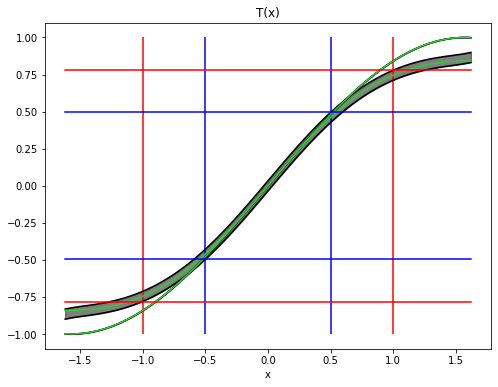

In [14]:

outer_bound = np.pi/2 + 0.05

# Coefficients
sin_x_coefs = np.array([
    1/62270208000, 0, -1/39916800, 0, 1/362880, 0, -1/5040, 0, 1/120, 0, -1/6, 0, 1, 0],
    dtype=np.float64)

# Remainder bounds
big_n = sin_x_coefs.shape[0]
sin_x_remainder = np.abs(outer_bound) ** (big_n + 1) / np.math.factorial(big_n + 1)

# Taylor models
t_sin_x = taylorm.TaylorModel(sin_x_coefs, -sin_x_remainder, sin_x_remainder)
t_result = taylorm.compose_taylor_models(
    t_sin_x, t_sin_x, -outer_bound, outer_bound, n_subdomains=10)

# Bound the result
domains = intvmath.IntervalColumnVector([
    intvmath.Interval(-0.5, 0.5),
    intvmath.Interval(-1., 1.0)
])

bounds_vector = t_result.bound_interval_vector(domains, n_subdomains=1000)

# Plot the Taylor models
ax = t_sin_x.plot(-outer_bound, outer_bound, n_points=100)
ax = t_result.plot(-outer_bound, outer_bound, n_points=100, ax=ax)

# Plot the true functions
x = np.linspace(-outer_bound, outer_bound, 50)
ax.plot(x, np.sin(x), color='limegreen')
ax.plot(x, np.sin(np.sin(x)), color='limegreen')

# Plot the bounds over selected subdomains
ax.plot(x, np.ones(x.shape) * bounds_vector.elems[0].x1, color='b')
ax.plot(x, np.ones(x.shape) * bounds_vector.elems[0].x2, color='b')    
ax.vlines(-0.5, -1, 1, color='b')
ax.vlines(0.5, -1, 1, color='b')

ax.plot(x, np.ones(x.shape) * bounds_vector.elems[1].x1, color='r')
ax.plot(x, np.ones(x.shape) * bounds_vector.elems[1].x2, color='r')
ax.vlines(-1, -1, 1, color='r')
ax.vlines(1, -1, 1, color='r')